### Task 1

In [60]:
import pandas as pd
import seaborn as sns

In [61]:
df= pd.read_csv('Housing.csv')

In [62]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [63]:
print(f'Number of rows in the dataset: {df.shape[0]}')
print(f'Number of columns in the dataset: {df.shape[1]}')

Number of rows in the dataset: 545
Number of columns in the dataset: 13


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [65]:
df.describe

<bound method NDFrame.describe of         price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       

 Real estate buyers and sellers often rely on guesswork or outdated comparisons to estimate a property's fair value. Our task is to build a regression model that predicts house prices based on property features such as size, number of rooms, location, and age — and then identify which features most strongly influence price.

 So the price is the target and all other columns are the features

In [66]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

So there are no missing values in any of the column

### Task 2
As there are no missing values so no need of fillna

In [67]:
df[df.duplicated()].count()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

There are no duplicate rows

In [68]:
for i in df.columns:
    print(f'Unique values in {i} column: {df[i].nunique()}')

Unique values in price column: 219
Unique values in area column: 284
Unique values in bedrooms column: 6
Unique values in bathrooms column: 4
Unique values in stories column: 4
Unique values in mainroad column: 2
Unique values in guestroom column: 2
Unique values in basement column: 2
Unique values in hotwaterheating column: 2
Unique values in airconditioning column: 2
Unique values in parking column: 4
Unique values in prefarea column: 2
Unique values in furnishingstatus column: 3


so there are categorical and numerical columns:

Categorical (Nominal): mainroad,	guestroom,	basement,	hotwaterheating,	airconditioning,	prefarea

Categorical (Ordinal): furnishingstatus

Numerical (Continuous): price, area

Numerical (Discrete): bedroom, bathrooms. stories,	parking

In [69]:
from sklearn.preprocessing import LabelEncoder
Lbl= LabelEncoder()

In [70]:
df['mainroad']= Lbl.fit_transform(df[['mainroad']])
df['guestroom']= Lbl.fit_transform(df[['guestroom']])
df['basement']= Lbl.fit_transform(df[['basement']])
df['hotwaterheating']= Lbl.fit_transform(df[['hotwaterheating']])
df['airconditioning']= Lbl.fit_transform(df[['airconditioning']])
df['prefarea']= Lbl.fit_transform(df[['prefarea']])


C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please ch

In [71]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,unfurnished
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,semi-furnished
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,unfurnished
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,furnished


In [72]:
from sklearn.preprocessing import OrdinalEncoder
encoder= OrdinalEncoder(categories= [['unfurnished', 'semi-furnished', 'furnished']])
df['furnishingstatus']= encoder.fit_transform(df[['furnishingstatus']])

In [73]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2.0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2.0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1.0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2.0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0.0
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1.0
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0.0
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,2.0


In [74]:
df.corr()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.296898,0.255517,0.187057,0.093073,0.452954,0.384394,0.329777,0.304721
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.288874,0.140297,0.047417,-0.009229,0.222393,0.352980,0.234779,0.171445
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,-0.012033,0.080549,0.097312,0.046049,0.160603,0.139270,0.079023,0.123244
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.042398,0.126469,0.102106,0.067159,0.186915,0.177496,0.063472,0.143559
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.121706,0.043538,-0.172394,0.018847,0.293602,0.045547,0.044425,0.104672
mainroad,0.296898,0.288874,-0.012033,0.042398,0.121706,1.000000,0.092337,0.044002,-0.011781,0.105423,0.204433,0.199876,0.156726
guestroom,0.255517,0.140297,0.080549,0.126469,0.043538,0.092337,1.000000,0.372066,-0.010308,0.138179,0.037466,0.160897,0.118328
basement,0.187057,0.047417,0.097312,0.102106,-0.172394,0.044002,0.372066,1.000000,0.004385,0.047341,0.051497,0.228083,0.112831
hotwaterheating,0.093073,-0.009229,0.046049,0.067159,0.018847,-0.011781,-0.010308,0.004385,1.000000,-0.130023,0.067864,-0.059411,0.031628
airconditioning,0.452954,0.222393,0.160603,0.186915,0.293602,0.105423,0.138179,0.047341,-0.130023,1.000000,0.159173,0.117382,0.150477


So the target column (price) is more  correlated to area, bedrooms, bathrooms, stories, airconditioning, parking, prefarea, furnishingstatus by taking covarience threshold of about 0.30

<Axes: >

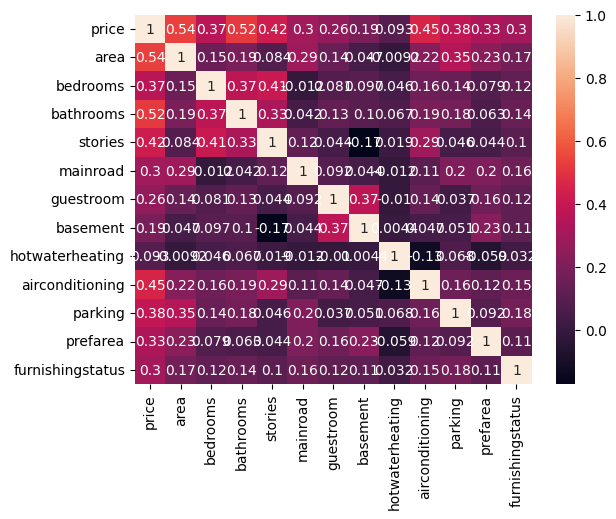

In [75]:
sns.heatmap(df.corr(), annot= True)

In [76]:
df= df.drop('mainroad', axis=1)
df= df.drop('guestroom', axis=1)
df= df.drop('basement', axis=1)
df= df.drop('hotwaterheating', axis=1)

In [77]:
df

,price,area,bedrooms,bathrooms,stories,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,2,1,2.0
1,12250000,8960,4,4,4,1,3,0,2.0
2,12250000,9960,3,2,2,0,2,1,1.0
3,12215000,7500,4,2,2,1,3,1,2.0
4,11410000,7420,4,1,2,1,2,0,2.0
...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,0,2,0,0.0
541,1767150,2400,3,1,1,0,0,0,1.0
542,1750000,3620,2,1,1,0,0,0,0.0
543,1750000,2910,3,1,1,0,0,0,2.0


## Feature Engineering

In [94]:
d= df['price'].min()
df['price']= df['price']//d

In [95]:
df

,price,area,bedrooms,bathrooms,stories,airconditioning,parking,prefarea,furnishingstatus
0,7,7420,4,2,3,1,2,1,2.0
1,7,8960,4,4,4,1,3,0,2.0
2,7,9960,3,2,2,0,2,1,1.0
3,6,7500,4,2,2,1,3,1,2.0
4,6,7420,4,1,2,1,2,0,2.0
...,...,...,...,...,...,...,...,...,...
540,1,3000,2,1,1,0,2,0,0.0
541,1,2400,3,1,1,0,0,0,1.0
542,1,3620,2,1,1,0,0,0,0.0
543,1,2910,3,1,1,0,0,0,2.0


In [96]:
df.corr()

,price,area,bedrooms,bathrooms,stories,airconditioning,parking,prefarea,furnishingstatus
price,1.000000,0.519510,0.366580,0.521582,0.410167,0.437951,0.379281,0.320603,0.301618
area,0.519510,1.000000,0.151858,0.193820,0.083996,0.222393,0.352980,0.234779,0.171445
bedrooms,0.366580,0.151858,1.000000,0.373930,0.408564,0.160603,0.139270,0.079023,0.123244
bathrooms,0.521582,0.193820,0.373930,1.000000,0.326165,0.186915,0.177496,0.063472,0.143559
stories,0.410167,0.083996,0.408564,0.326165,1.000000,0.293602,0.045547,0.044425,0.104672
airconditioning,0.437951,0.222393,0.160603,0.186915,0.293602,1.000000,0.159173,0.117382,0.150477
parking,0.379281,0.352980,0.139270,0.177496,0.045547,0.159173,1.000000,0.091627,0.177539
prefarea,0.320603,0.234779,0.079023,0.063472,0.044425,0.117382,0.091627,1.000000,0.107686
furnishingstatus,0.301618,0.171445,0.123244,0.143559,0.104672,0.150477,0.177539,0.107686,1.000000


## Task 3

In [97]:
from sklearn.model_selection import train_test_split
X= df.drop('price', axis=1)
y= df['price']

In [98]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

In [99]:
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}') 
print(f'y_test shape: {y_test.shape}')

X_train shape: (436, 8)
y_train shape: (436,)
X_test shape: (109, 8)
y_test shape: (109,)


In [100]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

model1= LinearRegression()

model1.fit(X_train, y_train)
y_pred1= model1.predict(X_test) 
mse1= mean_squared_error(y_test, y_pred1)
r2_1= r2_score(y_test, y_pred1)
rmse1= root_mean_squared_error(y_test, y_pred1)
print(f'Mean Squared Error for Linear Regression: {mse1}')
print(f'R-squared for Linear Regression: {r2_1}')
print(f'Root Mean Squared Error for Linear Regression: {rmse1}')

Mean Squared Error for Linear Regression: 0.6647233174119551
R-squared for Linear Regression: 0.5953280521535439
Root Mean Squared Error for Linear Regression: 0.815305658886258


In [102]:
from sklearn.ensemble import RandomForestRegressor

model2= RandomForestRegressor(n_estimators=100, random_state=42)

model2.fit(X_train, y_train)
y_pred2= model2.predict(X_test)
mse2= mean_squared_error(y_test, y_pred2)
r2_2= r2_score(y_test, y_pred2)
rmse2= root_mean_squared_error(y_test, y_pred2)
print(f'Mean Squared Error for Random Forest Regressor: {mse2}')
print(f'R-squared for Random Forest Regressor: {r2_2}')
print(f'Root Mean Squared Error for Random Forest Regressor: {rmse2}')

Mean Squared Error for Random Forest Regressor: 0.7016043172782874
R-squared for Random Forest Regressor: 0.5728755434728772
Root Mean Squared Error for Random Forest Regressor: 0.8376182407745711


## Task 4

In [105]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Frequency')

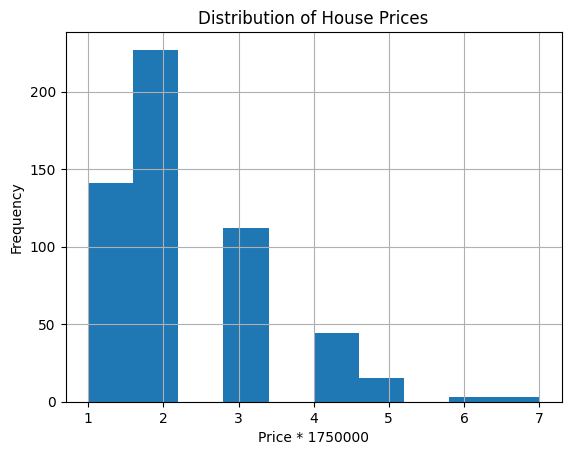

In [107]:
df['price'].hist()
plt.title('Distribution of House Prices')
plt.xlabel(f'Price * {d}')
plt.ylabel('Frequency')

<Axes: >

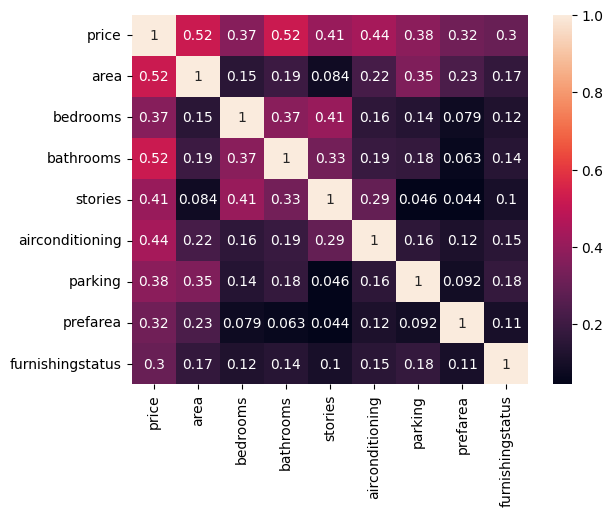

In [108]:
sns.heatmap(df.corr(), annot= True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7076\586508108.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


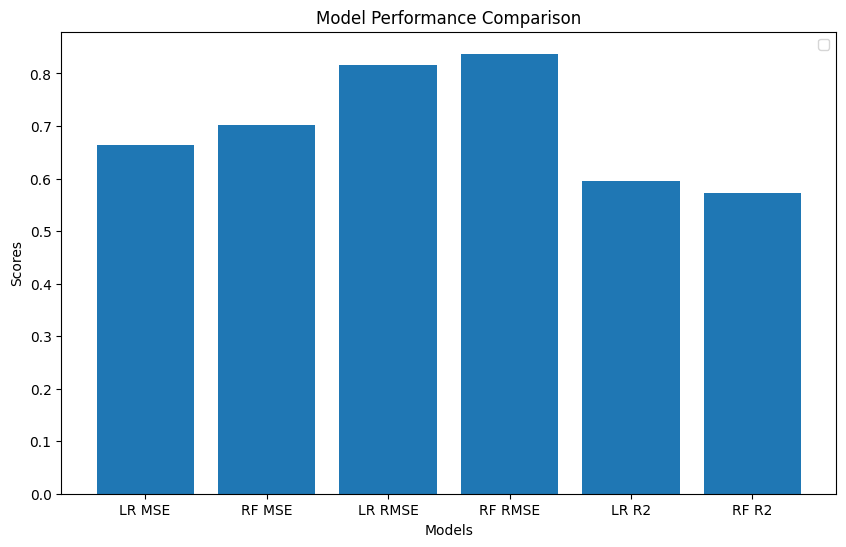

In [113]:
# MSE, RMSE, R2 Loss curve for Linear Regression and Random Forest Regressor
plt.figure(figsize=(10, 6))
# Plotting MSE
plt.bar(['LR MSE', 'RF MSE', 'LR RMSE', 'RF RMSE', 'LR R2', 'RF R2'], [mse1, mse2, rmse1, rmse2, r2_1, r2_2])
plt.title('Model Performance Comparison')
plt.xlabel('Models')
plt.ylabel('Scores')
plt.legend()

So Linear Regression shown better performance than Random Forest as its MSE and RMSE is lower and R sq is higher than its

## Task 5
Task 5 — Insights & Summary
 Write a short paragraph (5–8 lines) inside your notebook answering:

 Which features influence house price the most?
 
 How accurate was your model (in plain terms)?
 
 What surprised you in the data?
 
 One recommendation for a real estate business based on your findings

Answers:

The 'area' and 'bathroom' features influences the house price the most

My models are about 52% accurate

I am suprised by the fact that Random Forest and Linear Regression

More focus on the area of the building for the price prediction